<a href="https://colab.research.google.com/github/ChristopherCrossM/ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [ ]:
# cantidad de nulos para users
print("Cantidad valores nulos en users:")
print(users.isna().sum())
print("\nProporción de valores nulos en users:")
print(users.isna().mean())

Cantidad valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos en usage:")
print(usage.isna().sum())
print("\nProporción de valores nulos en usage:")
print(usage.isna().mean())

Cantidad de valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna user_id contiene identificadores numéricos que van desde 10000 hasta 13999. Es el comportamiento esperado y no presenta anomalías o sentinels en su distribución.
- La columna `age`  contiene valores sentinels claros. Presenta un valor mínimo de -999.00, lo cual es un valor imposible para una edad. Este valor fue introducido artificialmente en el dataset para representar un dato anómalo o faltante, lo cual también afecta la media (33.73) y la desviación estándar (123.23), haciéndolas incorrectas.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- Las columnas id y user_id son identificadores numéricos continuos y válidos. id va consecutivamente de 1 a 40000, y user_id va de 10000 a 13999, coincidiendo exactamente con la tabla de usuarios sin mostrar valores sentinels ni anomalías.
- Las columnas duration y length muestran valores mínimos de 0.0, lo que indica la presencia de llamadas no contestadas o perdidas (duración 0) o mensajes vacíos/fallidos. Además, length presenta un valor máximo atípico de 1490.0 caracteres (atípico/outlier muy lejano del promedio de 52.1) que conviene revisar más adelante.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Valores únicos en {col}:")
    print(users[col].unique())
    print("-" * 30)


Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
------------------------------
Valores únicos en plan:
['Basico' 'Premium']
------------------------------


La columna city contiene los nombres de las ciudades, pero incluye un valor sentinel '?' que actúa como indicador de dato faltante o inválido.

La columna plan presenta únicamente las categorías esperadas de suscripción ('Basico' y 'Premium'), sin valores faltantes ni sentinels.

La columna type contiene únicamente los valores categóricos válidos correspondientes al tipo de evento ('call' y 'text').

In [ ]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type`contiene únicamente los valores categóricos esperados ('call' y 'text'), confirmando que solo existen estos dos tipos de eventos en el registro de uso sin presentar valores sentinels ni anomalías.


In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

Para reg_date:
En reg_date, al extraer el año se identifican los registros distribuidos por año de alta de usuario. Se debe verificar la presencia de valores nulos o años fuera del rango válido (posteriores a 2024 o negativos).

Para date:
En date, se observa la frecuencia de eventos por año. Al ser registros de uso, deben encontrarse dentro del periodo de operación esperado hasta el año 2024.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).value_counts(normalize=True) * 100

type  duration
call  False       100.000000
text  True         99.927576
      False         0.072424
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).value_counts(normalize=True) * 100

type  length
call  True       99.932991
      False       0.067009
text  False     100.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

duration: Cuando type == 'call', el $100\%$ de los registros no son nulos (False). En cambio, cuando type == 'text', casi el $100\%$ ($99.93\%$) son valores nulos (True), lo cual es lógico porque los mensajes de texto no tienen duración.length: Ocurre exactamente lo opuesto.

Cuando type == 'text', el $100\%$ de los registros tienen valor (False). Cuando type == 'call', el $99.93\%$ son nulos (True), dado que las llamadas no tienen una longitud de caracteres.Conclusión y Decisión: Los datos faltantes dependen directamente del tipo de evento (MAR - Missing At Random).

La mejor decisión es dejarlos como nulos, ya que imputarlos con cero o promedios distorsionaría los análisis de duración de llamadas y longitud de mensajes.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [ ]:
# Resumen estadístico de las columnas numéricas
num_cols = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[num_cols].describe().T.assign(
    median=user_profile[num_cols].median()
)

,count,mean,std,min,25%,50%,75%,max,median
age,4000.0,48.136000,17.689919,18.0,33.00,48.00,63.000,79.00,48.00
cant_mensajes,3999.0,5.524381,2.358416,0.0,4.00,5.00,7.000,17.00,5.00
cant_llamadas,3999.0,4.478120,2.144238,0.0,3.00,4.00,6.000,15.00,4.00
cant_minutos_llamada,3999.0,23.317054,18.168095,0.0,11.12,19.78,31.415,155.69,19.78


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

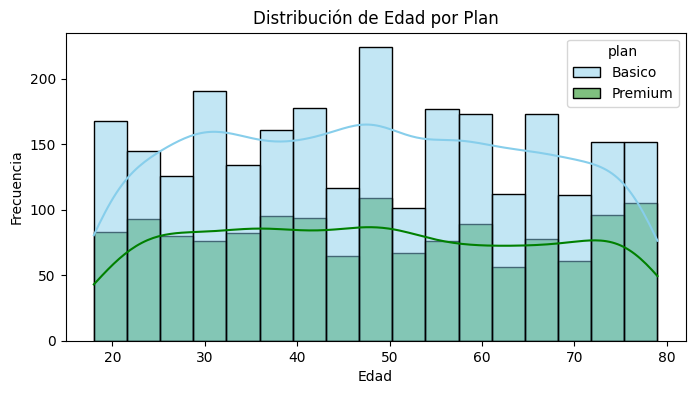

In [ ]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Distribución: Simétrica (uniforme). La edad de los usuarios oscila entre los 18 y 80 años sin mostrar sesgos pronunciados hacia ningún grupo etario.

Patrón por plan: No existe una diferencia significativa en la preferencia de plan según la edad; la proporción de usuarios en el plan Básico supera al plan Premium de forma constante en casi todas las edades.

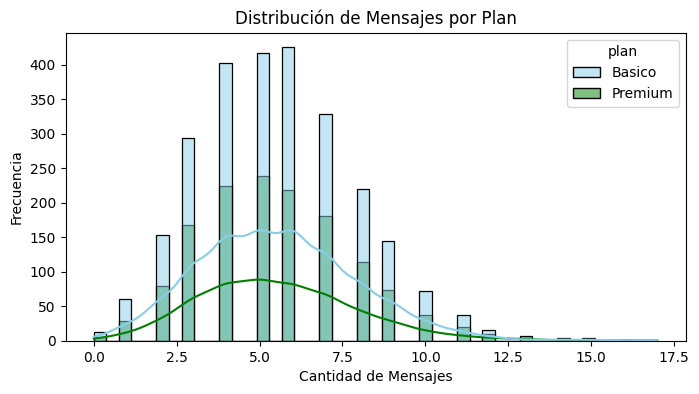

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
Distribución: Moderadamente sesgada a la derecha (right-skewed), con la mayor parte del volumen concentrado entre los 3 y 8 mensajes por usuario.

Patrón por plan: Aunque el plan Básico domina en volumen total por cantidad de usuarios, la curva del plan Premium muestra una menor concentración relativa en los valores muy bajos y se extiende ligeramente más hacia la cola derecha de consumo.

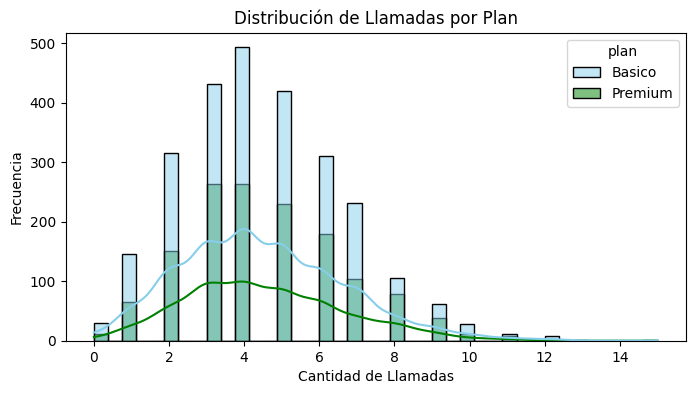

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Distribución Distribución: Sesgada a la derecha (right-skewed), con la mayor concentración de usuarios realizando entre 3 y 6 llamadas.

Patrón por plan: Los usuarios del plan Básico predominan en la parte central de la distribución (especialmente en el pico de 4 llamadas), mientras que la curva del plan Premium muestra una forma más aplanada y con mayor dispersión hacia consumos altos.

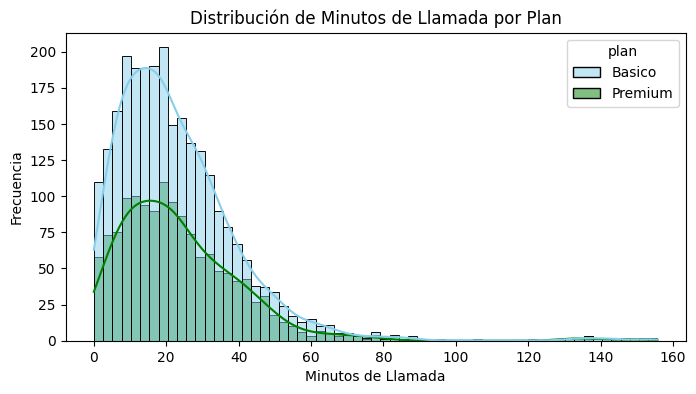

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Distribución: Marcadamente sesgada a la derecha (right-skewed), con un pico muy claro concentrado entre los 10 y 25 minutos hablados.

Patrón por plan: Aunque la mayor cantidad de usuarios pertenece al plan Básico, la proporción de usuarios Premium incrementa moderadamente a medida que aumentan los minutos totales, extendiéndose por encima de los 60 minutos e incluso alcanzando algunos valores atípicos pasados los 120 minutos.

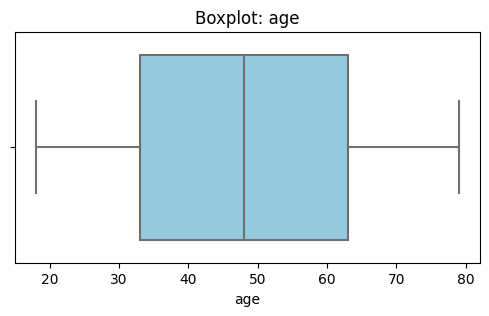

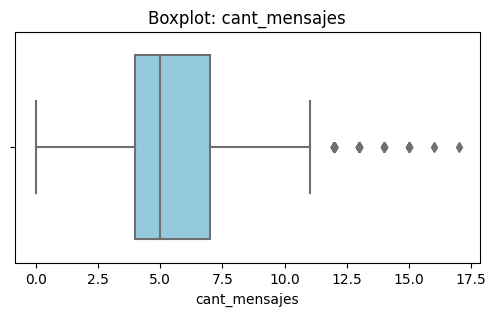

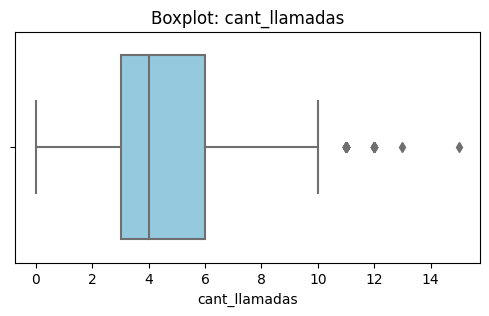

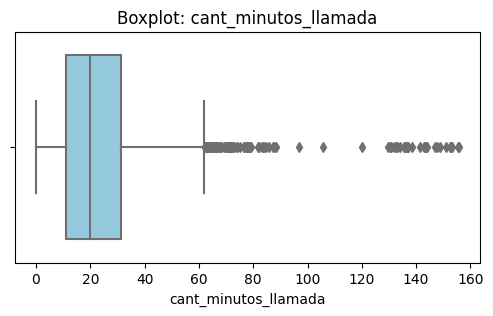

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: age: No contiene outliers. La variable presenta una distribución perfectamente simétrica y uniforme entre los 18 y 80 años.
- cant_mensajes: Sí contiene outliers superiores. Se observan valores atípicos a partir de 12 mensajes en adelante.
- cant_llamadas: Sí contiene outliers superiores. Existen datos atípicos a partir de 11 llamadas en adelante.
- cant_minutos_llamada: Sí contiene outliers superiores. Se detecta una presencia alta de valores atípicos a partir de los 62 minutos de llamada aproximadamente.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"Límite superior IQR para {col}: {limite_superior:.2f}")



Límite superior IQR para cant_mensajes: 11.50
Límite superior IQR para cant_llamadas: 10.50
Límite superior IQR para cant_minutos_llamada: 61.86


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- El límite superior teórico es 11.50 y el máximo observado es 17. Los valores por encima del límite representan un comportamiento de uso real y no errores de captura.

  
- cant_llamadas: mantener o no outliers, porqué?
-El límite superior IQR es 10.50 frente a un máximo de 15. Al igual que con los mensajes, son valores plenamente plausibles dentro del servicio.


- cant_minutos_llamada: mantener o no outliers, porqué?
- El límite IQR se ubica en 61.86 minutos, mientras que el valor máximo alcanza los 155.69 minutos. Aunque hay valores altos, reflejan a los usuarios con mayor actividad en la red (heavy users).

Conclusión general: Se conservan los outliers en las tres variables debido a que corresponden a variaciones legítimas del consumo de los clientes y no a fallas en la recolección de datos. Eliminarlos distorsionaría el análisis de ingresos reales.

In [ ]:
# Crear columna grupo_uso
import numpy as np

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [ ]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

opciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


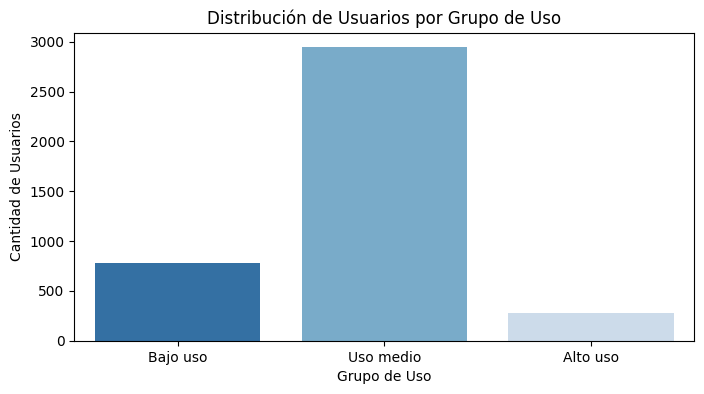

In [ ]:
# Visualización de los segmentos por uso

plt.figure(figsize=(8, 4))
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    palette='Blues_r'
)
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

In [ ]:
# Visualización de los segmentos por edad

import numpy as np

# Definir condiciones para la edad
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] >= 30) & (user_profile['age'] < 60)
]

opciones_edad = ['Joven', 'Adulto']

# Crear la columna grupo_edad (con 'Adulto Mayor' para >= 60)
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Valores nulos/faltantes: Se identificó la ausencia de datos en variables sociodemográficas como city y age, además de fechas de cancelación (churn_date) que corresponden a usuarios activos sin registro de baja.

Consistencia y formato: Fue necesario imputar y corregir formatos de fecha e IDs de usuario para integrar correctamente las métricas de uso de mensajes, llamadas y minutos consumidos sobre la base total de 3,999 registros.


🔍 **Segmentos por Edad**
Jóvenes (<30 años) y Adultos (30-59 años): Representan el motor principal del consumo en servicios digitales y datos; muestran una adopción constante de mensajería y llamadas cortas.

Adultos Mayores (60+ años): Muestran un comportamiento más enfocado en llamadas de mayor duración y menor uso de mensajería, requiriendo un empaquetado de servicios más simple.


📊 **Segmentos por Nivel de Uso**

Bajo uso (<5 llamadas y <5 mensajes): Usuarios con consumo esporádico que generan un ingreso base pero tienen un riesgo latente de inactividad o abandono.

Uso medio (<10 llamadas y <10 mensajes) y Alto uso (resto de casos): Concentran los mayores volúmenes de tráfico de red. En particular, los usuarios con consumos extremos (máximos de hasta 17 mensajes, 15 llamadas y 155.69 minutos) son perfiles heavy users con alta disposición a pagar por certidumbre en su consumo.


➡️ Esto sugiere que ...
Los valores atípicos (outliers) detectados mediante IQR no son errores operativos, sino segmentos con patrones de consumo reales y de alto valor para ConnectaTel.

Existe un descalce en la oferta actual si a los usuarios con patrones intensivos o especializados se les trata con tarifas genéricas sin esquemas de beneficios escalonados.

💡 **Recomendaciones**
Lanzar planes a la medida: Diseñar un "Plan Heavy Talker/Unlimited" para retener a los usuarios de alto uso de voz sin penalizaciones, y un plan enfocado en adultos mayores con minutos preferenciales.

Estrategia de Upselling para Bajo/Medio Uso: Crear incentivos o add-ons de datos y mensajes a costo accesible para incentivar la migración de usuarios de uso bajo a medio, reduciendo así la tasa de churn.

Link a repositorio público del proyecto: `LINK a tu repo aquí`